# Week 12 - Generative models

## Part 1: Probabilistic PCA (PPCA)


In this first part, we will implement PPCA in Pyro.


Import required libraries:


In [41]:
# Install Pyro, if necessary
!pip install pyro-ppl

In [42]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import linear_model
import seaborn as sns
import torch

import pyro
import pyro.distributions as dist
from pyro.contrib.autoguide import AutoDiagonalNormal, AutoMultivariateNormal, AutoNormal
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO
from pyro.optim import Adam, ClippedAdam

# fix random generator seed (for reproducibility of results)
np.random.seed(42)

# matplotlib style options
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

We will use the popular Iris dataset, that is often used to showcase clustering and dimensionality reduction techniques.
Conveniently for us, this dataset is available for us as part of sklearn. Lets load it as a Torch tensor:


In [43]:
# load csv
from sklearn import datasets
iris = datasets.load_iris()
X = torch.tensor(iris.data, dtype=torch.float32)
y = iris.target
y.shape, X.shape

((150,), torch.Size([150, 4]))

The dimensionality of our dataset is 150x4, i.e., 150 observations with 4 features:


In [44]:
X.shape

torch.Size([150, 4])

Lets standardize our data:


In [45]:
# standardize data
X = (X-X.mean(dim=0)) / X.std(dim=0)

## Probabilistic PCA in Pyro

Let's recap the generative process of PPCA from the lecture slides:

1. For each column $k \in \{1,\dots,K\}$ in the matrix $\textbf{W} = (\textbf{w}_1,\dots,\textbf{w}_K)^T$
   1. Sample $\textbf{w}_k \sim \mathcal{N}(\textbf{w}_k | \textbf{0}, \lambda\textbf{I})$

2. Sample $\boldsymbol\mu \sim \mathcal{N}(\boldsymbol\mu | \textbf{0}, \tau\textbf{I})$
3. Sample $\sigma^2 \sim \text{InvGamma}(\sigma^2 | \alpha, \beta)$
4. For each observation $n \in \{1,\dots,N\}$
   1. Sample latent projection $\textbf{z}_n \sim \mathcal{N}(\textbf{z}_n|\textbf{0}, \textbf{I})$
   2. Sample observation $\textbf{x}_n \sim \mathcal{N}(\textbf{x}_n|\textbf{W}\textbf{z}_n + \boldsymbol\mu, \sigma^2\textbf{I})$

Since our data is standardized, we can assume that $\boldsymbol\mu$ is zero, so we don't need to include it in our Pyro implementation. For $\sigma$, you can also use a HalfCauchy prior.

Note also that you can go for a fully vectorized implementation.

Let's try to implement this in Pyro. Can you do it? :-)


In [46]:
def ppca_model(X, latent_dim):
    input_dim = X.shape[1]
    N = X.shape[0]

    W = pyro.sample('W', dist.Normal(
        torch.zeros(input_dim, latent_dim), 
        torch.ones(input_dim, latent_dim)
    ).to_event(2))  # shape: [D, K]

    mu = pyro.sample("mu", dist.Normal(torch.zeros(input_dim), torch.ones(input_dim)).to_event(1))

    sigma = pyro.sample("sigma", dist.InverseGamma(torch.ones(1), torch.ones(1)))

    with pyro.plate("N_plate", N):
        z_n = pyro.sample("z_n", dist.Normal(
            torch.zeros(latent_dim), 
            torch.ones(latent_dim)
        ).to_event(1))  # shape: [N, K]

        x = pyro.sample("x_n", dist.Normal(
            z_n @ W.T + mu,               # (N,K) @ (K,D) → (N,D)
            sigma.sqrt() * torch.ones(input_dim)
        ).to_event(1), obs=X)

    return x

In [47]:
%%time

# Define guide function
#guide = AutoDiagonalNormal(ppca_model)
guide = AutoNormal(ppca_model)

# Reset parameter values
pyro.clear_param_store()

# Define the number of optimization steps
n_steps = 12000

# Setup the optimizer
adam_params = {"lr": 0.005}
optimizer = ClippedAdam(adam_params)

# Setup the inference algorithm
elbo = Trace_ELBO(num_particles=3)
svi = SVI(ppca_model, guide, optimizer, loss=elbo)

# Do gradient steps
for step in range(n_steps):
    elbo = svi.step(X, 2)
    if step % 500 == 0:
        print("[%d] ELBO: %.1f" % (step, elbo))

[0] ELBO: 1419.8
[500] ELBO: 633.1
[1000] ELBO: 619.4
[1500] ELBO: 620.2
[2000] ELBO: 623.4
[2500] ELBO: 623.0
[3000] ELBO: 616.8
[3500] ELBO: 618.0
[4000] ELBO: 615.9
[4500] ELBO: 615.9
[5000] ELBO: 613.2
[5500] ELBO: 612.7
[6000] ELBO: 610.9
[6500] ELBO: 608.3
[7000] ELBO: 608.5
[7500] ELBO: 610.3
[8000] ELBO: 606.3
[8500] ELBO: 608.8
[9000] ELBO: 609.5
[9500] ELBO: 608.8
[10000] ELBO: 611.9
[10500] ELBO: 611.5
[11000] ELBO: 610.5
[11500] ELBO: 612.2
CPU times: user 1min 25s, sys: 616 ms, total: 1min 26s
Wall time: 1min 27s


Lets now get samples from the posterior distributions of w and z by accessing the means of their respective Gaussian approximations in the variational distribution:


In [48]:
z_mean = pyro.get_param_store().get_param("AutoNormal.locs.z_n").detach().numpy()
w_mean = pyro.get_param_store().get_param("AutoNormal.locs.W").detach().numpy()

We begin by making a scatter plot of the projected data points in the latent (z) space. We will color-code the data points in the projected data according to their true class (y).


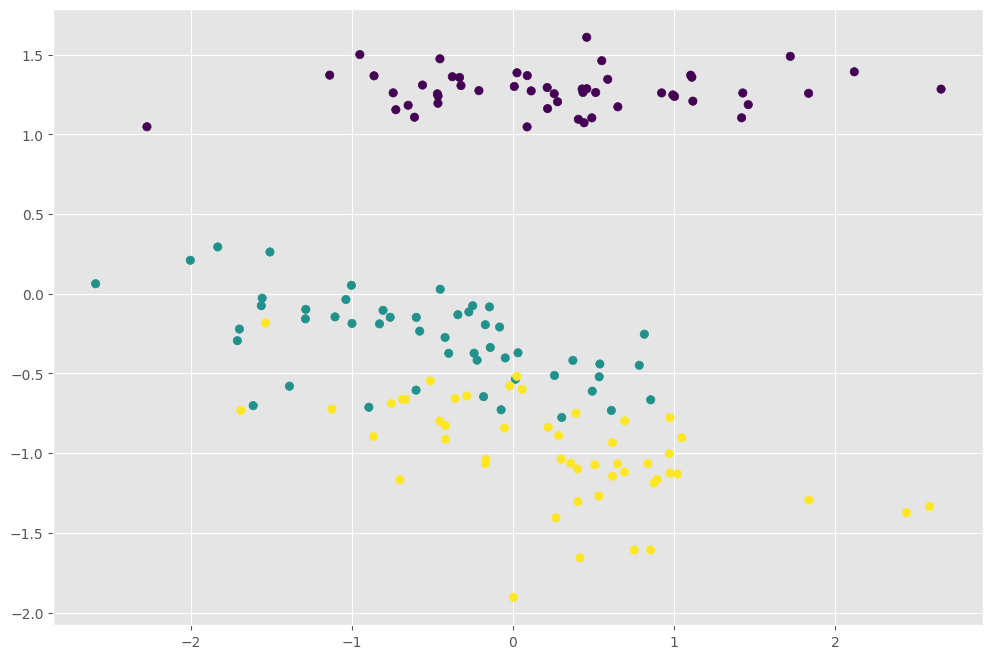

In [49]:
plt.scatter(z_mean[:,0], z_mean[:,1], c=y);

As we can see, the projection does a decent job at perserving the separability between the different classes.

Lets now use both z and w to reconstruct our data point in their original input space - i.e. we are reversing the projection by moving back to original coordinates:


In [50]:
reconstruction = np.matmul(z_mean, w_mean.T)

Obviously, since the dimensionality of the latent space is lower than the original input space, the reconstruction comes with an error associated. Lets now measure that error using MAE and RMSE:


In [51]:
mae = torch.mean(torch.abs(X-reconstruction))
rmse = torch.sqrt(torch.mean((X-reconstruction)**2))
mae, rmse

/var/folders/sm/bpqf8wpj6478c8rtz31k076r0000gn/T/ipykernel_94646/1556782401.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mae = torch.mean(torch.abs(X-reconstruction))
/var/folders/sm/bpqf8wpj6478c8rtz31k076r0000gn/T/ipykernel_94646/1556782401.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rmse = torch.sqrt(torch.mean((X-reconstruction)**2))


(tensor(0.1588), tensor(0.2131))

We can now use the generative capabilities of our model to sample new "fake" observations from our PPCA model:


In [52]:
# generate 1000 fake data points
fake_data = torch.matmul(torch.randn((1000,2)).unsqueeze(0), torch.tensor(w_mean).T).mean(dim=0)
fake_data

tensor([[ 0.4436,  0.0897,  0.3828,  0.3805],
        [ 1.2865, -0.8403,  1.5159,  1.4508],
        [-0.5897,  0.2489, -0.6446, -0.6220],
        ...,
        [-0.0791,  0.6334, -0.3077, -0.2727],
        [-0.2248,  0.4475, -0.3757, -0.3483],
        [ 0.8622,  0.4367,  0.6473,  0.6568]])